# 6. Decision Trees and Ensemble Learning


## 🎯 Context and Aim

This project aims to build a predictive model for credit risk scoring using decision trees and ensemble learning techniques. In a typical banking context, when a client applies for a loan (e.g., to buy a phone), the bank must assess whether to grant or deny the loan. The goal of this project is to train machine learning models that estimate the **probability of default** (risk that a customer will not repay) based on historical data. This is a **binary classification problem** where the output variable indicates either *default* or *no default*. The dataset used, `credit_scoring.csv`, contains various features like income, expenses, loan amount, and categorical variables (homeownership, marital status, etc.).

In [1]:
import pandas as pd
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
# sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import export_text

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'
# !wget $data
!head ./Data/CreditScoring.csv


"Status","Seniority","Home","Time","Age","Marital","Records","Job","Expenses","Income","Assets","Debt","Amount","Price"
1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
1,0,1,36,26,1,1,1,46,107,0,0,310,910
1,1,2,60,36,2,1,1,75,214,3500,0,650,1645
1,29,2,60,44,2,1,1,75,125,10000,0,1600,1800
1,9,5,12,27,1,1,1,35,80,0,0,200,1093
1,0,2,60,32,2,1,3,90,107,15000,0,1200,1957


# Data Preparation
Raw data may have:
* Encoded categorical variables (e.g., 1 = rent, 2 = owner)
* Missing values (e.g., 999999 for income)
* Non-standardized column names
  Cleaning includes decoding categorical values, treating missing data, filtering, and splitting into train/val/test sets.





In [55]:
df = pd.read_csv('Data/CreditScoring.csv')
df.columns = df.columns.str.lower()


Categorical variables are represented by numbers. For converting Categorical variables, we'll use the following map

In [56]:
# transform numerical values to categorical
status_values = {
    1: 'ok',
    2:'default',
    0: 'unk'
}
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}
marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}
records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}
job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

# map number to string
df.status = df.status.map(status_values)
df.home = df.home.map(home_values)
df.marital = df.marital.map(marital_values)
df.records = df.records.map(records_values)
df.job = df.job.map(job_values)

df.head(2)


,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658


In [57]:
boolean_mask = df.dtypes == 'object'

categorical = list(df.dtypes[boolean_mask].index)
print('categorical' , categorical )

numerical  = list(df.dtypes[~boolean_mask].index)
print('numerical' , numerical )

df[categorical].nunique()

categorical ['status', 'home', 'marital', 'records', 'job']
numerical ['seniority', 'time', 'age', 'expenses', 'income', 'assets', 'debt', 'amount', 'price']


status     3
home       7
marital    6
records    2
job        5
dtype: int64

In [6]:
# Stats for the dataset
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


Some of the missing value where replaced by 99999999, let's replace them

In [58]:
for i in ['income', 'assets', 'debt']:
    df[i] = df[i].replace(to_replace = 99999999, value = np.nan )

df.isna().sum()

status        0
seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

In [60]:
# exclude the unk value from the data This ensures that the model is trained only on rows where we know if the person defaulted or not (i.e., labels ok or default), avoiding label noise.
df = df[df.status != 'unk'].reset_index(drop=True)
df_origin = df.copy()
print(df.status.value_counts())

status
ok         3200
default    1254
Name: count, dtype: int64


### split the data into training sets

In [9]:
def prepare_data(df):

    # split in train (60%), validation (20%) and test (20%)
    # 0.8 and 0.2
    df_train_full, df_test = train_test_split(df, test_size = 0.2,  random_state = 11)
    # 0.75 * 0.8 = 0.6 and  0.25 * 0.8 = 0.2
    df_train, df_val = train_test_split(df_train_full, test_size = 0.25 ,  random_state = 11)

    df_train.reset_index(drop = True)
    df_val.reset_index(drop = True)
    df_train_full.reset_index(drop = True)

    # y is “True/1” if the client defaulted and “False/0” otherwise
    y_train_full = (df_train_full.status == 'default').astype(int).values
    y_test = (df_test.status == 'default').astype(int).values
    y_train = (df_train.status == 'default').astype(int).values
    y_val = (df_val.status == 'default').astype(int).values

    del df_train['status']
    del df_train_full['status']
    del df_test['status']
    del df_val['status']

    df_train_full = df_train_full.fillna(0)
    df_test = df_test.fillna(0)
    df_train = df_train.fillna(0)
    df_val = df_val.fillna(0)

    dict_train_full = df_train_full.to_dict(orient = 'records')
    dict_test = df_test.to_dict(orient = 'records')
    dict_train = df_train.to_dict(orient = 'records')
    dict_val = df_val.to_dict(orient = 'records')

    dv = DictVectorizer(sparse = False)
    X_train_full = dv.fit_transform(dict_train_full)
    X_train = dv.transform(dict_train)
    X_test = dv.transform(dict_test)
    X_val = dv.transform(dict_val)

    return X_train_full,X_test, X_train, X_val, y_train_full, y_test, y_train, y_val, dv

X_train_full, X_test, X_train, X_val, y_train_full, y_test, y_train, y_val, dv = prepare_data(df)
y_train

array([1, 1, 0, ..., 0, 0, 0], shape=(2672,))

## 6.3 Decision trees

Decision trees learn rules in the form of if/else logic based on feature thresholds. The tree recursively splits the dataset until leaves predict a target value.
Risk: if the tree is too deep, it **overfits** the training data.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.7054989859726213
val: 0.6685264343319367


In [11]:
dt_full = DecisionTreeClassifier()
dt_full.fit(X_train, y_train)
max_possible_depth = dt_full.get_depth()
print("Maximum possible depth:", max_possible_depth)

Maximum possible depth: 19


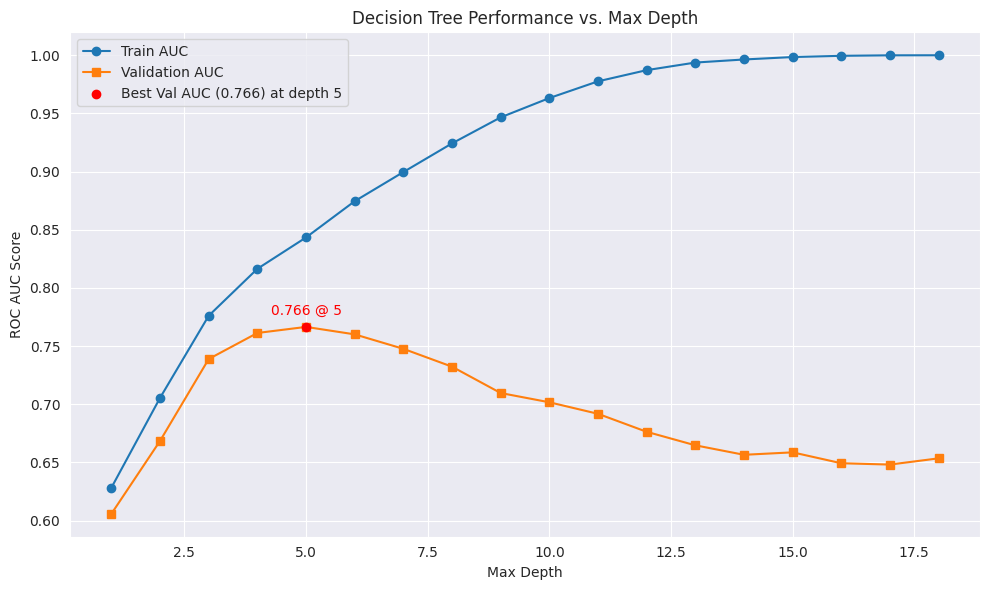

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split


# Store results
max_depths = range(1, max_possible_depth)
train_auc = []
val_auc = []

for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict_proba(X_train)[:, 1]
    y_val_pred = dt.predict_proba(X_val)[:, 1]

    train_auc.append(roc_auc_score(y_train, y_train_pred))
    val_auc.append(roc_auc_score(y_val, y_val_pred))

# Plotting

# Find the best validation AUC and corresponding depth
best_idx = np.argmax(val_auc)
best_depth = max_depths[best_idx]
best_val_auc = val_auc[best_idx]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_auc, label='Train AUC', marker='o')
plt.plot(max_depths, val_auc, label='Validation AUC', marker='s')
plt.scatter(best_depth, best_val_auc, color='red', zorder=5, label=f'Best Val AUC ({best_val_auc:.3f}) at depth {best_depth}')
plt.text(best_depth, best_val_auc + 0.01, f'{best_val_auc:.3f} @ {best_depth}', color='red', ha='center')

plt.xlabel('Max Depth')
plt.ylabel('ROC AUC Score')
plt.title('Decision Tree Performance vs. Max Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 🔍 **1. Training AUC keeps increasing**

* The **Train AUC** increases steadily and approaches **1.0** as `max_depth` increases.
* This is expected: a deeper tree can perfectly memorize the training data (i.e., **overfitting**).

---

### ⚠️ **2. Validation AUC peaks then declines**

* The **Validation AUC** increases up to around `max_depth ≈ 5`, then **starts to drop**.
* This suggests that **generalization performance is best around depth 4–6**.
* After that, adding depth leads to **overfitting**: the tree captures noise in the training data, hurting performance on unseen data.

* **Best validation AUC is at depth \~5**. That’s likely the best trade-off between underfitting and overfitting.

### 📌 Summary

| Depth | Observation                                            |
| ----- | ------------------------------------------------------ |
| 1–3   | Underfitting: train and val AUC both low               |
| 4–6   | Good generalization                                    |
| >6    | Overfitting: train AUC continues rising, val AUC drops |



## 6.4 Decision tree learning algorithm
### ✅ Goal

Understand how decision trees choose the best splits during training.
* Finding the best split for one column
* Finding the best split for the entire dataset
* Stopping criteria
* Decision tree learning algorithm
### 🧠 Concept

At each node, the algorithm tries all possible thresholds for all features and selects the one minimizing impurity (e.g., Gini, entropy, misclassification rate).


We create a small dataset of clients with `assets` and `status`, then sort it to prepare for manual threshold analysis like a decision tree would do.



In [13]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example.sort_values('assets')


,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


### 🔍 Evaluate a split at threshold T = 4000

We split the dataset into two groups:
- `df_left`: clients with `assets ≤ T`
- `df_right`: clients with `assets > T`

Then we inspect the class distribution (`status`) in each group to evaluate how "pure" the split is — just like a decision tree does when choosing the best threshold.


In [14]:
Ts = [0, 2000, 3000, 4000, 5000, 8000]
T = 4000
df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
print(df_left.status.value_counts(normalize=True))
display(df_right)
print(df_left.status.value_counts(normalize=True))

,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


### 📊 Loop over thresholds to find best split

We test several thresholds `T` to split the dataset into left/right groups based on `assets`.

For each split:
- We compute the class decision (most frequent label)
- We calculate the impurity (1 - max class probability) on both sides
- We compute the average impurity

The best threshold is the one that minimizes this average impurity — simulating how a decision tree chooses its split.


In [15]:
import pandas as pd

# Input data
data = [
    [8000, 'default'],
    [2000, 'default'],
    [0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]
df_example = pd.DataFrame(data, columns=['assets', 'status'])

# Possible split thresholds
Ts = [0, 2000, 3000, 4000, 5000, 8000]

# Table to store results
results = []

# Helper to compute impurity as 1 - max class probability (classification error)
def impurity(series):
    counts = series.value_counts(normalize=True)
    return 1 - counts.max()

# Evaluate each threshold
for T in Ts:
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    decision_left = df_left['status'].mode()[0] if not df_left.empty else None
    decision_right = df_right['status'].mode()[0] if not df_right.empty else None

    impurity_left = impurity(df_left['status']) if not df_left.empty else None
    impurity_right = impurity(df_right['status']) if not df_right.empty else None

    # Average impurity (simple average, assuming equal weight)
    avg_impurity = None
    if impurity_left is not None and impurity_right is not None:
        avg_impurity = round((impurity_left + impurity_right) / 2, 4)

    results.append({
        'T': T,
        'Decision Left': decision_left,
        'Impurity Left': impurity_left,
        'Decision Right': decision_right,
        'Impurity Right': impurity_right,
        'Avg Impurity': avg_impurity
    })

# Convert to DataFrame and display
df_results = pd.DataFrame(results)
print(df_results)
best_row = df_results['T'].loc[df_results["Avg Impurity"].idxmin()]
best_imp = df_results["Avg Impurity"].loc[df_results["Avg Impurity"].idxmin()]
print(f"Best result is T : {best_row}, Avg Impurity : {best_imp}")

      T Decision Left  Impurity Left Decision Right  Impurity Right  \
0     0       default       0.000000             ok        0.428571   
1  2000       default       0.000000             ok        0.333333   
2  3000       default       0.000000             ok        0.200000   
3  4000       default       0.250000             ok        0.250000   
4  5000       default       0.500000        default        0.500000   
5  8000       default       0.428571             ok        0.000000   

   Avg Impurity  
0        0.2143  
1        0.1667  
2        0.1000  
3        0.2500  
4        0.5000  
5        0.2143  
Best result is T : 3000, Avg Impurity : 0.1


In [16]:
import pandas as pd

# Input data extended with a 'debt' column for demonstration
data = [
    [8000, 1000, 'default'],
    [2000, 2000, 'default'],
    [0,    1500, 'default'],
    [5000, 500,  'ok'],
    [5000, 1500, 'ok'],
    [4000, 500,  'ok'],
    [9000, 500,  'ok'],
    [3000, 500,  'default'],
]
df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])

# Define thresholds per feature
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

# Store all results
results = []

# Impurity: classification error
def impurity(series):
    counts = series.value_counts(normalize=True)
    return 1 - counts.max()

# Evaluate splits for each feature and threshold
for feature, Ts in thresholds.items():
    for T in Ts:
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]

        decision_left = df_left['status'].mode()[0] if not df_left.empty else None
        decision_right = df_right['status'].mode()[0] if not df_right.empty else None

        impurity_left = impurity(df_left['status']) if not df_left.empty else None
        impurity_right = impurity(df_right['status']) if not df_right.empty else None

        avg_impurity = None
        if impurity_left is not None and impurity_right is not None:
            avg_impurity = round((impurity_left + impurity_right) / 2, 4)

        results.append({
            'Feature': feature,
            'T': T,
            'Decision Left': decision_left,
            'Impurity Left': impurity_left,
            'Decision Right': decision_right,
            'Impurity Right': impurity_right,
            'Avg Impurity': avg_impurity
        })

# Create DataFrame and find best split
df_results = pd.DataFrame(results)
best_row = df_results.loc[df_results["Avg Impurity"].idxmin()]
best_row


Feature            assets
T                    3000
Decision Left     default
Impurity Left         0.0
Decision Right         ok
Impurity Right        0.2
Avg Impurity          0.1
Name: 2, dtype: object

In [17]:
import pandas as pd

# Input data with 'debt' column
data = [
    [8000, 1000, 'default'],
    [2000, 2000, 'default'],
    [0,    1500, 'default'],
    [5000, 500,  'ok'],
    [5000, 1500, 'ok'],
    [4000, 500,  'ok'],
    [9000, 500,  'ok'],
    [3000, 500,  'default'],
]
df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])

# Thresholds
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

# Impurity functions
def impurity(series):
    if series.empty:
        return 0
    counts = series.value_counts(normalize=True)
    return 1 - counts.max()

def avg_impurity(left, right):
    return (len(left) * impurity(left['status']) + len(right) * impurity(right['status'])) / (len(left) + len(right))

def best_subsplit_with_threshold(df, feature, Ts):
    if df.empty:
        return None, 0

    best_t = None
    best_impurity = float('inf')

    for t in Ts:
        left = df[df[feature] <= t]
        right = df[df[feature] > t]
        imp = avg_impurity(left, right)
        if imp < best_impurity:
            best_impurity = imp
            best_t = t

    return best_t, best_impurity

# === Assets → Debt ===
best_assets = min(
    thresholds['assets'],
    key=lambda t: avg_impurity(
        df_example[df_example['assets'] <= t],
        df_example[df_example['assets'] > t]
    )
)
df_left_assets = df_example[df_example['assets'] <= best_assets]
df_right_assets = df_example[df_example['assets'] > best_assets]

best_debt_left, impurity_left = best_subsplit_with_threshold(df_left_assets, 'debt', thresholds['debt'])
best_debt_right, impurity_right = best_subsplit_with_threshold(df_right_assets, 'debt', thresholds['debt'])

impurity_a_d = (
    len(df_left_assets) * impurity_left + len(df_right_assets) * impurity_right
) / len(df_example)

# === Debt → Assets ===
best_debt = min(
    thresholds['debt'],
    key=lambda t: avg_impurity(
        df_example[df_example['debt'] <= t],
        df_example[df_example['debt'] > t]
    )
)
df_left_debt = df_example[df_example['debt'] <= best_debt]
df_right_debt = df_example[df_example['debt'] > best_debt]

best_assets_left, impurity_left = best_subsplit_with_threshold(df_left_debt, 'assets', thresholds['assets'])
best_assets_right, impurity_right = best_subsplit_with_threshold(df_right_debt, 'assets', thresholds['assets'])

impurity_d_a = (
    len(df_left_debt) * impurity_left + len(df_right_debt) * impurity_right
) / len(df_example)

# Final summary
{
    "Assets → Debt": {
        "Total Impurity": round(impurity_a_d, 4),
        "Best Threshold (Assets)": best_assets,
        "Best Debt Threshold (Left child)": best_debt_left,
        "Best Debt Threshold (Right child)": best_debt_right,
    },
    "Debt → Assets": {
        "Total Impurity": round(impurity_d_a, 4),
        "Best Threshold (Debt)": best_debt,
        "Best Assets Threshold (Left child)": best_assets_left,
        "Best Assets Threshold (Right child)": best_assets_right,
    }
}


{'Assets → Debt': {'Total Impurity': np.float64(0.125),
  'Best Threshold (Assets)': 3000,
  'Best Debt Threshold (Left child)': 500,
  'Best Debt Threshold (Right child)': 2000},
 'Debt → Assets': {'Total Impurity': np.float64(0.125),
  'Best Threshold (Debt)': 500,
  'Best Assets Threshold (Left child)': 3000,
  'Best Assets Threshold (Right child)': 0}}

Here are the results of the **2-level split comparison**:

| Split Order       | Total Impurity |
| ----------------- | -------------- |
| **Debt → Assets** | `0.125`        |
| **Assets → Debt** | `0.125`        |

🎯 In this case, **both split sequences give the same final impurity**, up to floating point precision.

➡️ That means either split order could be chosen first — though in real datasets, one order often performs better.


Perfect — let’s now enhance the **goal section** to better explain the **meaning and purpose** behind doing this two-level split analysis.

---

### 🎯 **Goal & Meaning of the Analysis**

We aim to simulate how a decision tree algorithm chooses the **best split path** by comparing different feature-threshold combinations. Specifically:

* 🔍 **Why?**
  To understand how decision trees **build their structure**: at each node, they search for the split that best separates the classes (`status`), by minimizing impurity.

* 🧩 **What we do:**
  Try two strategies:

  1. First split on `assets`, then split each child on `debt`
  2. First split on `debt`, then split each child on `assets`

* 📉 **What we measure:**
  The **total classification error** (impurity) after two levels of splitting.

* 🧠 **Why it matters:**
  This helps us understand:

  * How trees **grow recursively**
  * How the **first decision** influences the entire structure
  * Why greedy split selection doesn't always guarantee the global best tree

By computing and comparing impurity at each level, we **see how the tree "thinks"** when choosing splits — which is fundamental in model interpretability and performance tuning.



## 6.5 Decision trees parameter tuning


We aim to find the optimal values for the parameters ``max_depth`` and ``min_samples_leaf``.

- The ``max_depth`` parameter indicates the maximum depth of the tree. It is the longest path from the tree root to a leaf. t's a measure of the maximum amount of overfitting that can occur. Lower values will make the model more conservative and prevent overfitting by ensuring that it doesn't learn the training data too well, but can potentially underfit if the depth is set too low.

- The ``min_samples_leaf`` parameter is the minimum number of samples required to be at a leaf node. This parameter is very effective in smoothing the model, especially in regression. When this parameter is small, leaves can have very few samples, resulting in a model that captures a lot of detail and possibly noise. When this parameter is large, the tree becomes more constrained as it has to consider more samples at each leaf.

In [18]:
scores = []
from sklearn.tree import DecisionTreeClassifier

for depth in max_depths:
    for s in [1, 5, 10, 15, 20, 500, 100, 200]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((depth, s, auc))
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns='max_depth', values='auc')
df_scores_pivot.round(3)


max_depth,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
min_samples_leaf,,,,,,,,,,,,,,,,,,
1,0.606,0.669,0.739,0.761,0.766,0.762,0.754,0.727,0.700,0.686,0.693,0.679,0.666,0.675,0.661,0.658,0.654,0.667
5,0.606,0.669,0.739,0.761,0.768,0.763,0.757,0.743,0.745,0.726,0.717,0.712,0.712,0.719,0.720,0.716,0.715,0.714
10,0.606,0.669,0.739,0.761,0.762,0.778,0.764,0.761,0.766,0.769,0.767,0.765,0.763,0.759,0.764,0.763,0.759,0.762
15,0.606,0.669,0.738,0.764,0.772,0.785,0.780,0.780,0.787,0.789,0.788,0.789,0.789,0.787,0.787,0.786,0.786,0.787
20,0.606,0.669,0.736,0.761,0.774,0.774,0.779,0.778,0.786,0.785,0.784,0.782,0.780,0.781,0.779,0.781,0.784,0.784
100,0.606,0.669,0.736,0.756,0.763,0.776,0.780,0.779,0.780,0.779,0.779,0.779,0.779,0.779,0.780,0.779,0.780,0.780
200,0.606,0.669,0.729,0.747,0.759,0.768,0.768,0.768,0.768,0.768,0.768,0.768,0.768,0.768,0.768,0.768,0.768,0.768
500,0.620,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680,0.680


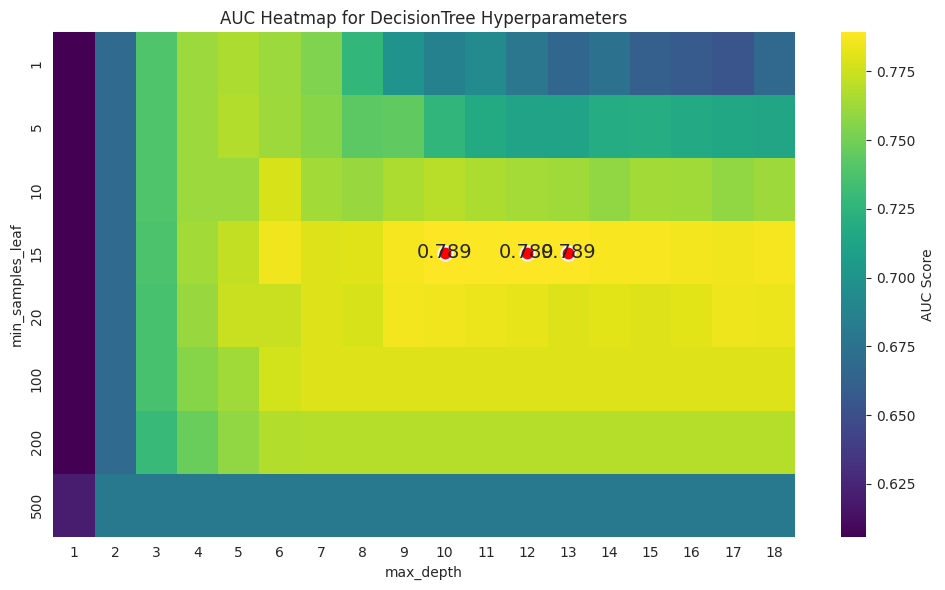

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create empty string DataFrame for annotation (safe from dtype issues)
annot = pd.DataFrame("", index=df_scores_pivot.index, columns=df_scores_pivot.columns)

# Find top 3 best (depth, min_samples_leaf) points
top3 = df_scores.sort_values("auc", ascending=False).head(3)

# Fill only top 3 values in the annot DataFrame
for _, row in top3.iterrows():
    i = df_scores_pivot.index.get_loc(row['min_samples_leaf'])
    j = df_scores_pivot.columns.get_loc(row['max_depth'])
    annot.iloc[i, j] = f"{row['auc']:.3f}"


# Plot heatmap with selective annotations
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    df_scores_pivot,
    cmap="viridis",
    annot=annot,
    fmt="",
    cbar_kws={'label': 'AUC Score'},
    annot_kws={"size": 14}  # <-- Increase annotation font size here
)


# Plot red circles at top 3 locations
for _, row in top3.iterrows():
    x = df_scores_pivot.columns.get_loc(row['max_depth'])
    y = df_scores_pivot.index.get_loc(row['min_samples_leaf'])
    ax.plot(x + 0.5, y + 0.5, 'ro', markersize=10, markeredgecolor='white', markeredgewidth=1.5)

# Add labels
plt.title("AUC Heatmap for DecisionTree Hyperparameters")
plt.xlabel("max_depth")
plt.ylabel("min_samples_leaf")
plt.tight_layout()
plt.show()


In [20]:

best_row = top3.loc[top3["auc"].idxmax()]
top3

,max_depth,min_samples_leaf,auc
75,10,15,0.789167
91,12,15,0.788979
99,13,15,0.788668


In [21]:
best_DecisionTreeClassifier = df_scores.sort_values("auc", ascending=False).head(1)
best_DecisionTreeClassifier

,max_depth,min_samples_leaf,auc
75,10,15,0.789167


In [22]:
dt = DecisionTreeClassifier(max_depth=int(best_row['max_depth']), min_samples_leaf=int(best_row['min_samples_leaf']))
dt.fit(X_train, y_train)
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- income <= 20.00
|   |   |   |   |   |--- seniority <= 1.50
|   |   |   |   |   |   |--- age <= 37.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- age >  37.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- seniority >  1.50
|   |   |   |   |   |   |--- assets <= 2450.00
|   |   |   |   |   |   |   |--- marital=married <= 0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- marital=married >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- assets >  2450.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- income >  20.00
|   |   |   |   |   |--- expenses <= 71.00
|   |   |   |   |   |   |--- amount <= 795.00
|   |   |   |   |   |   |   |--- price <= 950.50
|   |   |   |   |   |   |   |   |--- amount <= 487.50
|   |   |   |   |   

## ✅ Conclusion: Decision Tree Parameter Tuning

We evaluated combinations of `max_depth` and `min_samples_leaf` to find the best-performing model using AUC on a validation set.

A heatmap was used to visualize results, with the top 3 parameter combinations highlighted.

The **best model** achieved an AUC of **{:.3f}** with:

* `max_depth = {10}`
* `min_samples_leaf = {15}`


### 6.6 Random Forest

🔁 **From Single Tree to Ensemble Learning**

While 6.5 showed how hyperparameter tuning can balance depth and generalization for a single decision tree, Random Forest goes a step further by building many such trees and averaging their predictions. This ensemble method improves **robustness**, **stability**, and **generalization**.

This transition represents a shift:

* **From focusing on one well-tuned tree**,
* **To building many simpler trees trained on slightly different data and features**.

By introducing randomness in both **rows (bootstrap samples)** and **columns (random feature subsets)**, Random Forest reduces variance and avoids the fragility of individual trees — even if that one tree seemed “good enough.”

---

| Aspect               | **6.5 – Single Decision Tree**      | **6.6 – Random Forest Ensemble**        |
| -------------------- | ----------------------------------- | --------------------------------------- |
| **Goal**             | Tune one tree to reduce overfitting | Combine many trees for stability        |
| **Model Type**       | One interpretable tree              | An ensemble of randomized trees         |
| **Training Data**    | Full data used for one tree         | Bootstrap samples (rows + features)     |
| **Variance**         | High (sensitive to noise)           | Low (averaged predictions)              |
| **Bias**             | Can be very low (deep trees)        | Slightly higher, but generalizes better |
| **Overfitting Risk** | High if tree is too deep            | Low, even with many trees               |
| **Interpretability** | Very high (tree is readable)        | Lower (individual trees are hidden)     |

---

🎯 **Goal**
Use ensembling (Random Forest) to improve prediction stability and performance over a single decision tree.

🧠 **Concept**
Random Forest builds multiple decision trees on bootstrapped samples of the data and aggregates their predictions. This ensemble approach reduces variance and overfitting, while maintaining good interpretability. The randomness comes from sampling rows and subsets of features.

🛠️ **Tasks**

* Train Random Forest with increasing number of trees (`n_estimators`)
* Tune `max_depth` and `min_samples_leaf` jointly
* Plot AUC as function of tree count and depth
* Evaluate stability of model performance

💡 **Note**
Random Forest tends to outperform a single tree without requiring heavy tuning. It’s less prone to overfitting, especially with many trees.


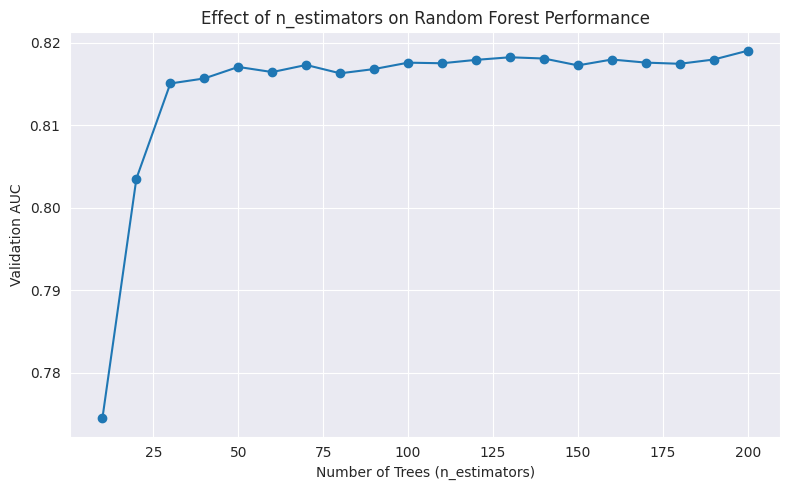

In [23]:

scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

# 📊 Plot
plt.figure(figsize=(8, 5))
plt.plot(df_scores.n_estimators, df_scores.auc, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Validation AUC")
plt.title("Effect of n_estimators on Random Forest Performance")
plt.grid(True)
plt.tight_layout()
plt.show()



### 🧠 How `n_estimators` Fits with Other Tree Parameters

* `n_estimators` = **number of trees** in the forest.
* Each tree is trained on:

  * A **random subset of rows** (bootstrap sample),
  * A **random subset of features** (at each split),
  * Using the same **tree rules**: `max_depth`, `min_samples_leaf`, and threshold-based splitting.

| Parameter          | Scope     | Role                                |
| ------------------ | --------- | ----------------------------------- |
| `max_depth`        | Per tree  | Limits how deep a tree can grow     |
| `min_samples_leaf` | Per tree  | Avoids splits on very small groups  |
| Feature columns    | Per split | Tree chooses which feature to split |
| Thresholds         | Per split | Best value to split on              |
| `n_estimators`     | Forest    | How many diverse trees to average   |

👉 Each tree is different due to randomness. Averaging predictions reduces variance and gives more stable, robust performance than any one tree alone.


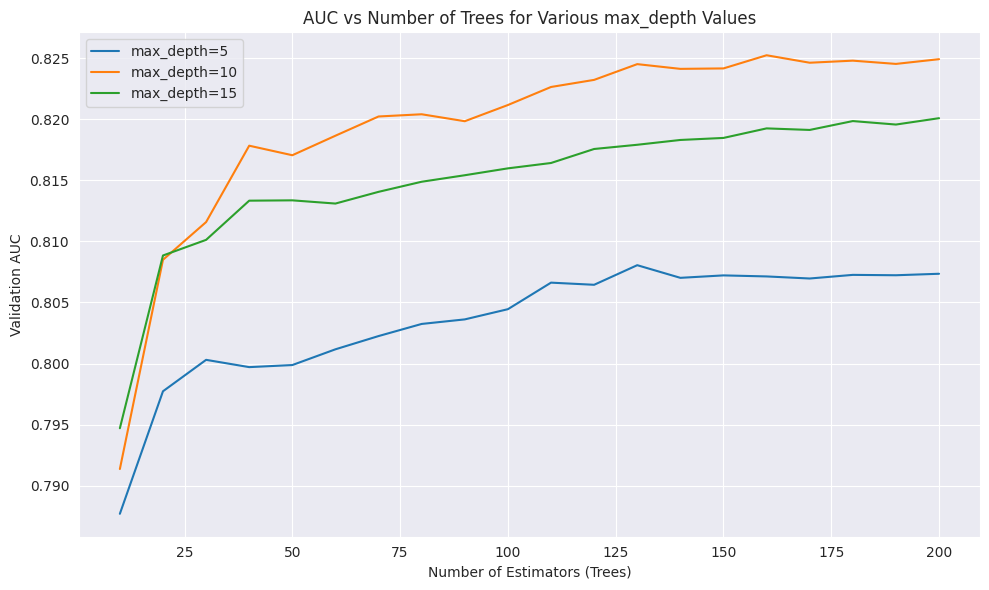

In [24]:


# --- Phase 1: Tune max_depth ---
scores_depth = []
depth_values = [5, 10, 15]
n_estimators_range = range(10, 201, 10)

for d in depth_values:
    for n in n_estimators_range:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores_depth.append((d, n, auc))

df_depth = pd.DataFrame(scores_depth, columns=['max_depth', 'n_estimators', 'auc'])

# Plotting AUC vs n_estimators for different max_depth
plt.figure(figsize=(10, 6))
for d in depth_values:
    df_subset = df_depth[df_depth.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label=f'max_depth={d}')
plt.title("AUC vs Number of Trees for Various max_depth Values")
plt.xlabel("Number of Estimators (Trees)")
plt.ylabel("Validation AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

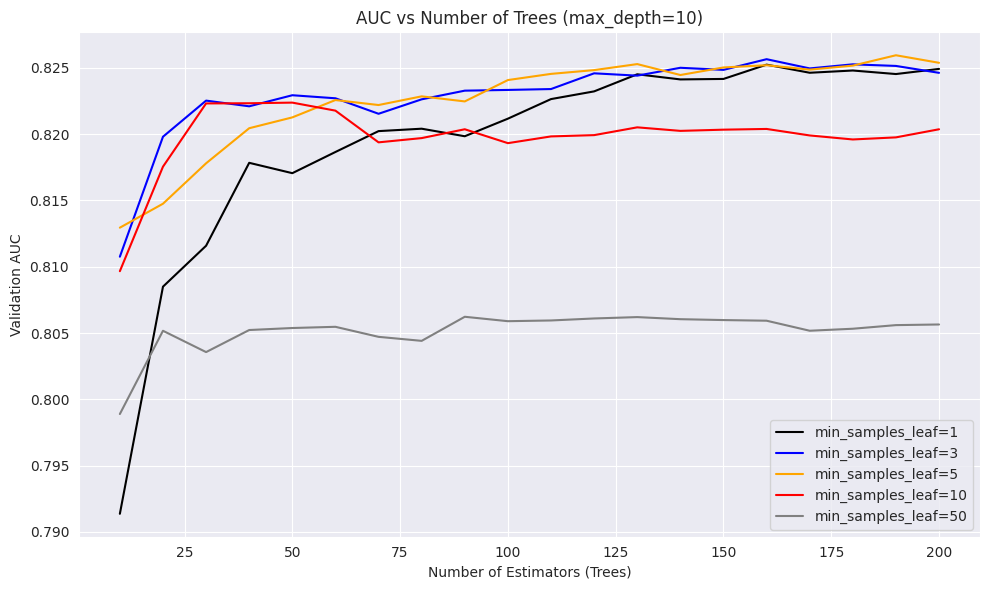

In [25]:
# --- Phase 2: Tune min_samples_leaf ---
scores_leaf = []
leaf_values = [1, 3, 5, 10, 50]
chosen_max_depth = 10

for s in leaf_values:
    for n in n_estimators_range:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=chosen_max_depth,
            min_samples_leaf=s,
            random_state=1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores_leaf.append((s, n, auc))

df_leaf = pd.DataFrame(scores_leaf, columns=['min_samples_leaf', 'n_estimators', 'auc'])

# Plotting AUC vs n_estimators for different min_samples_leaf values
plt.figure(figsize=(10, 6))
colors = ['black', 'blue', 'orange', 'red', 'grey']

for s, col in zip(leaf_values, colors):
    df_subset = df_leaf[df_leaf.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, color=col, label=f'min_samples_leaf={s}')
plt.title(f"AUC vs Number of Trees (max_depth={chosen_max_depth})")
plt.xlabel("Number of Estimators (Trees)")
plt.ylabel("Validation AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_RandomForestClassifier = {'min_samples_leaf' : 5, 'n_estimators' : 125, 'max_depths' : 10}

In **6.6**, we manually tuned `max_depth` and `min_samples_leaf` to improve Random Forest performance. This ensemble approach helped reduce overfitting by combining multiple independent decision trees trained on random data subsets.

But Random Forest has its limits:

### 🧠 Why Random Forest tuning (6.6) is *limited*

| Limitation                    | Description                                                               |
| ----------------------------- | ------------------------------------------------------------------------- |
| ⚙️ **Manual tuning**          | Coarse grid search; hard to explore all parameter combinations            |
| 🌲 **Independent trees**      | Each tree is trained in isolation; no error correction from previous ones |
| 🌀 **No learning dynamics**   | The model doesn’t learn from mistakes — no "feedback loop" between trees  |
| ⏱️ **Costly experimentation** | Increasing tree count or depth has high computational cost                |

---



## 6.7 – Gradient Boosting and XGBoost

🎯 **Goal**
Introduce boosting and train the first **XGBoost** model while observing its behavior during training.


🧠 **Concept**
Gradient Boosting builds models **sequentially**, each new tree aiming to **correct the errors** of the combined ensemble so far.
**XGBoost** is an optimized, fast, and regularized version of this algorithm — especially good for tabular data.


#### From Random Forest (6.6) to Gradient Boosting (6.7)

Gradient Boosting — and especially its powerful implementation **XGBoost** — is designed to **overcome these shortcomings**  (6.6) by learning in a more structured way.

| Concept                    | **Random Forest (6.6)**        | **Gradient Boosting (6.7)**                      |
| -------------------------- | ------------------------------ | ------------------------------------------------ |
| **Tree Training**          | In parallel, independently     | Sequentially — each tree improves the last       |
| **Error Handling**         | None — no correction mechanism | Learns from **residual errors** at each step     |
| **Tuning Strategy**        | Manual, grid-based, rigid      | Fine-grained via `learning_rate`, `n_estimators` |
| **Learning Control**       | Very limited                   | Flexible, precise learning with `eta`            |
| **Performance Monitoring** | Not built-in                   | Built-in training log (AUC per boosting round)   |


> Instead of relying on the **averaging of uncoordinated trees** (Random Forest), Gradient Boosting focuses on **learning from past errors** — step by step.
> This makes it **more powerful**, but also **more sensitive** and **hyperparameter-dependent**.

---
🛠️ **Tasks**

* Install and configure `xgboost`
* Train an initial model with default hyperparameters
* Monitor **AUC evolution** round-by-round
* Parse and visualize **training vs validation performance**

💡 **Note**
XGBoost often **outperforms Random Forest** on structured datasets, but requires more **careful tuning** (learning rate, depth, early stopping…) to avoid overfitting.




In [26]:
%%capture output

import xgboost as xgb

features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [27]:
features

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unk',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unk',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=unk',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

In [28]:
%%capture output
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [29]:
s = output.stdout


[0]	train-auc:0.86653	val-auc:0.77999
[5]	train-auc:0.92969	val-auc:0.80822
[10]	train-auc:0.95512	val-auc:0.81115
[15]	train-auc:0.96767	val-auc:0.81993
[20]	train-auc:0.97648	val-auc:0.81877
[25]	tr


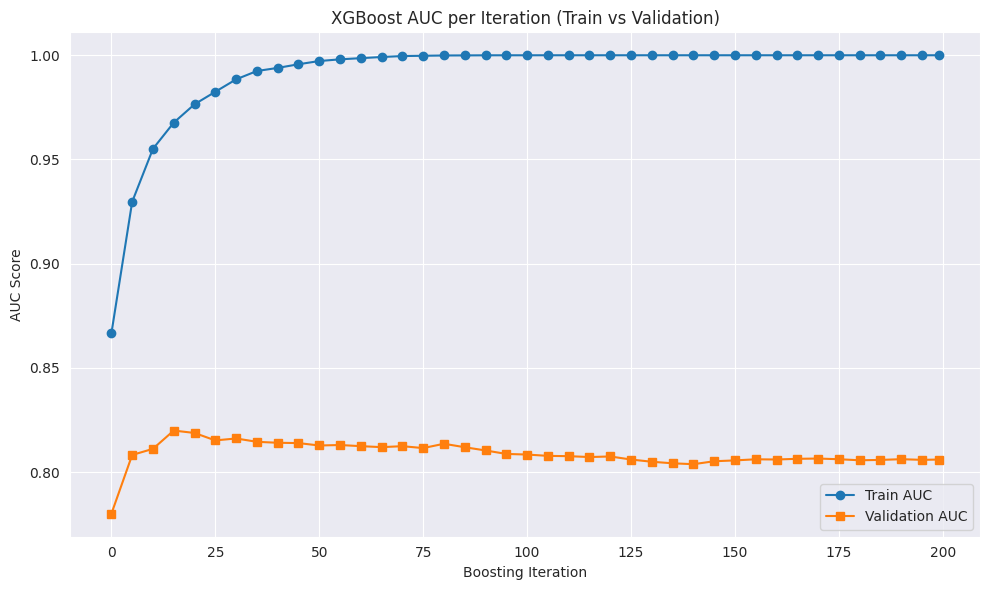

In [30]:

print(s[:200])


def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results


df_score = parse_xgb_output(output)
plt.figure(figsize=(10, 6))
plt.plot(df_score.num_iter, df_score.train_auc, label='Train AUC', marker='o')
plt.plot(df_score.num_iter, df_score.val_auc, label='Validation AUC', marker='s')

plt.xlabel('Boosting Iteration')
plt.ylabel('AUC Score')
plt.title('XGBoost AUC per Iteration (Train vs Validation)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




## 📊 Explaining the Curve in 6.7

### 🟦 **Train AUC**

* Grows rapidly to \~1.0
* Each new tree improves the model on the training set
* Classic sign: model **can fit training data perfectly**

### 🟧 **Validation AUC**

* Rises initially (until \~20 rounds), then **drops or plateaus**
* This is **overfitting**: the model starts to memorize quirks in the training data that don't help with new/unseen data
* The early boost shows that boosting is working — but after that, it’s hurting

---


## 🔁 Comparing 6.3 and 6.7: Similar curve, Different Algorithm

| Aspect                   | **6.3 – Decision Tree (One Tree)**             | **6.7 – XGBoost (Boosted Trees)**                   |
| ------------------------ | ---------------------------------------------- | --------------------------------------------------- |
| 📦 Model Type            | A single tree                                  | A sequence of trees (boosting)                      |
| 🔍 Iteration Meaning     | Increasing `max_depth` of **one tree**         | Adding **more trees** (boosting rounds)             |
| 🎯 Training Strategy     | One-pass training (fit full tree once)         | Incremental: each tree fixes previous residuals     |
| ⚠️ Overfitting Mechanism | Tree too deep memorizes training data          | Too many boosting rounds → model overfits gradually |
| 🧪 Goal of AUC Curve     | Find optimal **tree depth** for generalization | Find best **number of boosting rounds**             |

---

## 🧠 Why This Happens in Boosting (and Not in Single Trees)

* In **6.3**, you test static models: one tree, one fitting phase.
* In **6.7**, the model keeps **adapting and evolving**, which allows for powerful corrections — but also means it's easier to go **too far**.
* Without **early stopping**, XGBoost will keep adding trees even when they start doing harm on validation data.





## 🔍 Further Key Points to Add After the Summary

### ✅ **Why XGBoost Is Still Powerful (Despite Overfitting Risk)**

* XGBoost trains each tree to fix **what the previous trees got wrong**.
* This creates a very **focused, adaptive learner**.
* It often outperforms Random Forest **when tuned well** (with early stopping, learning rate control, etc.).
* Boosting is better at **capturing subtle patterns**, especially in **imbalanced or noisy datasets**.

---

### 🔧 **How to Avoid Overfitting in Boosting**

| Strategy                        | Description                                                                   |
| ------------------------------- | ----------------------------------------------------------------------------- |
| `early_stopping_rounds`         | Stop training if validation score hasn’t improved for N rounds                |
| `learning_rate` (eta)           | Shrinks each tree’s contribution → slows overfitting, improves generalization |
| `max_depth`                     | Shallower trees generalize better → typically 3–6 for boosting                |
| `subsample`, `colsample_bytree` | Add randomness (like Random Forest) to prevent overfitting                    |

---

### 🔁 **Compared to Random Forest (6.6)**

| Topic               | **Random Forest**                  | **XGBoost**                              |
| ------------------- | ---------------------------------- | ---------------------------------------- |
| Tree dependency     | Independent trees                  | Sequential (each corrects the last)      |
| Risk of overfitting | Lower, saturates early             | Higher, especially with too many rounds  |
| Performance scaling | Stable as trees increase (plateau) | Peaks then drops if unchecked            |
| Parallelization     | Yes (fully parallelizable)         | Limited (trees depend on previous ones)  |
| Tuning importance   | Moderate (depth, leaves)           | High (learning rate, rounds, early stop) |

---

### 📈 Final Thought

> The key difference is that **Random Forest "averages weak learners"**, while **Boosting "builds a strong learner" progressively** — so XGBoost can go further, but it needs tighter control.




### 6.8 XGBoost Parameter Tuning

🎯 **Goal**
Fine-tune XGBoost to maximize performance on validation data without overfitting.

🧠 **Concept**
XGBoost has many hyperparameters; tuning the learning rate (`eta`), depth (`max_depth`), and minimum weight (`min_child_weight`) can greatly affect performance. A small `eta` with many rounds allows more precise adjustments. Larger `min_child_weight` values act as regularizers.

🛠️ **Tasks**

* Grid search over combinations of `eta`, `max_depth`, `min_child_weight`
* Plot AUC as function of boosting round
* Select optimal configuration based on validation AUC curves

💡 **Note**: Boosting with high `eta` may overfit quickly; low `eta` leads to better generalization but slower convergence. Tuning is crucial for robust performance.


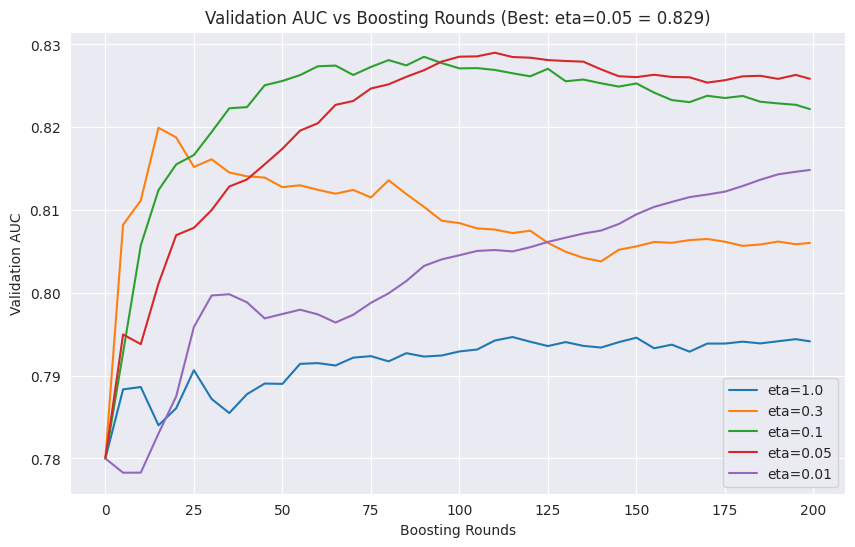

✅ Best eta: eta=0.05, AUC: 0.829


In [31]:


etas = [1.0, 0.3, 0.1, 0.05, 0.01]
scores = {}

for eta in etas:
    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 0,
    }

    # Train & capture
    output = None
    from IPython.utils import io
    with io.capture_output() as output:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=watchlist,
            verbose_eval=5
        )

    key = f"eta={eta}"
    scores[key] = parse_xgb_output(output)

# Plot
plt.figure(figsize=(10, 6))
best_auc = 0
best_eta = None

for label, df in scores.items():
    plt.plot(df.num_iter, df.val_auc, label=label)

    max_val_auc = df.val_auc.max()
    if max_val_auc > best_auc:
        best_auc = max_val_auc
        best_eta = label

plt.title(f'Validation AUC vs Boosting Rounds (Best: {best_eta} = {best_auc:.3f})')
plt.xlabel('Boosting Rounds')
plt.ylabel('Validation AUC')
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ Best eta: {best_eta}, AUC: {best_auc:.3f}")


In [32]:
best_eta

'eta=0.05'

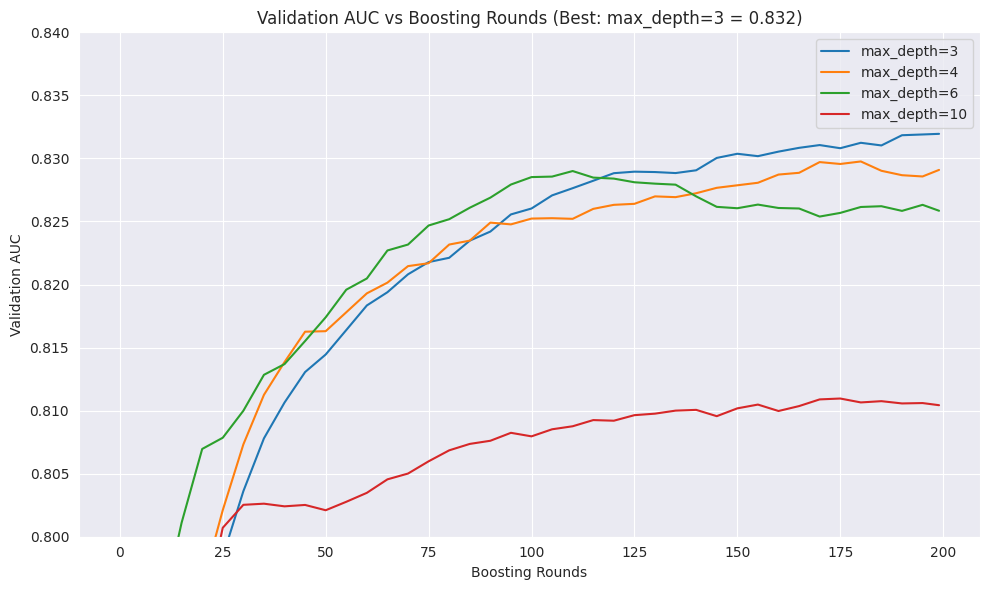

'max_depth=3'

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from IPython.utils import io

# Define the range of max_depth values to try
max_depths = [3, 4, 6, 10]
scores = {}

# Run experiments
for max_depth in max_depths:
    xgb_params = {
        'eta': 0.05,
        'max_depth': max_depth,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 0,
    }

    with io.capture_output() as output:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=watchlist,
            verbose_eval=5
        )

    key = f"max_depth={max_depth}"
    scores[key] = parse_xgb_output(output)

# Determine best max_depth
best_auc = 0
best_depth = None

plt.figure(figsize=(10, 6))
for label, df in scores.items():
    plt.plot(df.num_iter, df.val_auc, label=label)
    max_val_auc = df.val_auc.max()
    if max_val_auc > best_auc:
        best_auc = max_val_auc
        best_depth = label

plt.title(f'Validation AUC vs Boosting Rounds (Best: {best_depth} = {best_auc:.3f})')
plt.xlabel('Boosting Rounds')
plt.ylabel('Validation AUC')
plt.ylim(0.8, 0.84)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_depth


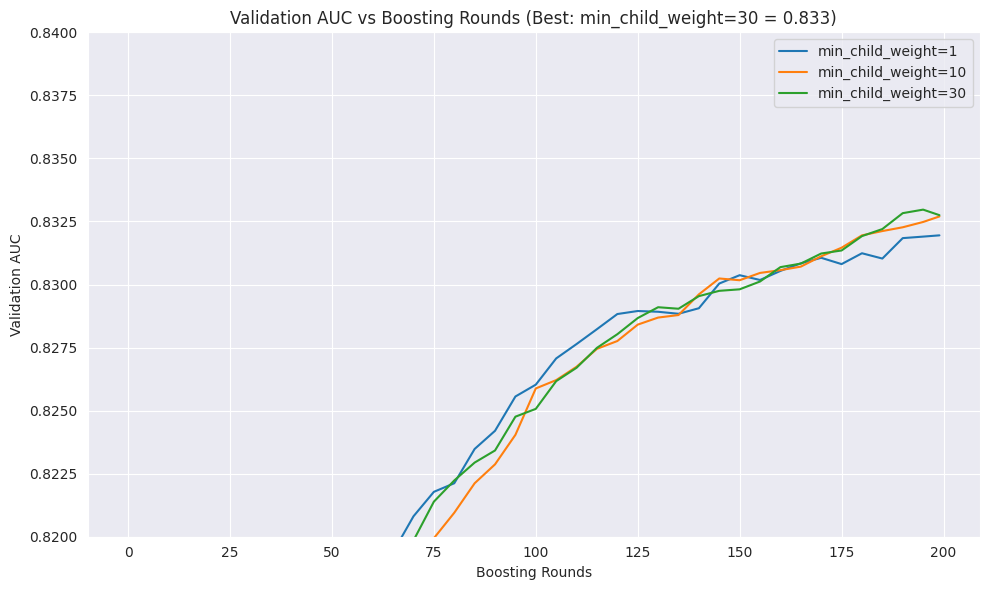

('min_child_weight=30', np.float64(0.83297))

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from IPython.utils import io

# Define the range of min_child_weight values to try
min_child_weights = [1, 10, 30]
scores = {}

# Run experiments
for min_child_weight in min_child_weights:
    xgb_params = {
        'eta': 0.05,
        'max_depth': 3,
        'min_child_weight': min_child_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 0,
    }

    with io.capture_output() as output:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=watchlist,
            verbose_eval=5
        )

    key = f"min_child_weight={min_child_weight}"
    scores[key] = parse_xgb_output(output)

# Determine best min_child_weight
best_auc = 0
best_weight = None

plt.figure(figsize=(10, 6))
for label, df in scores.items():
    plt.plot(df.num_iter, df.val_auc, label=label)
    max_val_auc = df.val_auc.max()
    if max_val_auc > best_auc:
        best_auc = max_val_auc
        best_weight = label

plt.title(f'Validation AUC vs Boosting Rounds (Best: {best_weight} = {best_auc:.3f})')
plt.xlabel('Boosting Rounds')
plt.ylabel('Validation AUC')
plt.ylim(0.82, 0.84)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_weight,best_auc



## ✅ XGBoost Hyperparameter Tuning Summary

Tuned in recommended order:

### 1️⃣ `eta` (learning rate)

* **Tested**: 1.0, 0.3, 0.1, 0.05, 0.01
* **Best**: `eta = 0.05` → Balanced learning, good AUC without overfitting

### 2️⃣ `max_depth`

* **Tested**: 3, 4, 6, 10
* **Best**: `max_depth = 3` → Simpler trees, better generalization

### 3️⃣ `min_child_weight`

* **Tested**: 1, 10, 30
* **Best**: `min_child_weight = 30` → Added regularization, reduced overfitting

---

## 🏁 Final Model Params

```python
xgb_params = {
    'eta': 0.05,
    'max_depth': 3,
    'min_child_weight': 30,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    'seed': 1
}
```



In [35]:
import numpy as np
import pandas as pd
from itertools import product
import xgboost as xgb
from IPython.utils import io

# Define your resolution (number of steps per parameter)

# Smart ranges
etas = np.logspace(-2, 0, 10)             # 0.01 → 1.0 (log scale)
depths = np.linspace(3, 10, 10, dtype=int)  # depth: 3 to 10
min_weights = np.logspace(0, 2, 10, dtype=int)  # 1 to 100 (log scale)

param_combinations = list(product(etas, depths, min_weights))
results = []

for eta, max_depth, min_child_weight in param_combinations:
    xgb_params = {
        'eta': float(eta),
        'max_depth': int(max_depth),
        'min_child_weight': int(min_child_weight),
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 0,
    }

    with io.capture_output() as output:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=watchlist,
            verbose_eval=5
        )

    df_score = parse_xgb_output(output)
    max_val_auc = df_score['val_auc'].max()

    results.append({
        'eta': round(float(eta), 5),
        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'val_auc': round(max_val_auc, 5)
    })

df_results = pd.DataFrame(results)
df_results.sort_values(by='val_auc', ascending=False).head()


,eta,max_depth,min_child_weight,val_auc
665,0.21544,7,12,0.83930
647,0.21544,6,35,0.83927
657,0.21544,6,35,0.83927
727,0.35938,4,35,0.83793
537,0.12915,5,35,0.83792


In [36]:
import pandas as pd
import xgboost as xgb
from itertools import product
from IPython.utils import io

def run_xgb_grid_search(dtrain, watchlist, etas, max_depths, min_weights, num_boost_round=200, seed=1, nthread=8):
    param_combinations = list(product(etas, max_depths, min_weights))
    results = []

    for eta, max_depth, min_child_weight in param_combinations:
        xgb_params = {
            'eta': float(eta),
            'max_depth': int(max_depth),
            'min_child_weight': int(min_child_weight),
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'nthread': nthread,
            'seed': seed,
            'verbosity': 0,
        }

        with io.capture_output() as output:
            model = xgb.train(
                xgb_params,
                dtrain,
                num_boost_round=num_boost_round,
                evals=watchlist,
                verbose_eval=5
            )

        df_score = parse_xgb_output(output)
        max_val_auc = df_score['val_auc'].max()

        results.append({
            'eta': round(float(eta), 5),
            'max_depth': max_depth,
            'min_child_weight': min_child_weight,
            'val_auc': round(max_val_auc, 5)
        })

    df_results = pd.DataFrame(results)
    return df_results.sort_values(by='val_auc', ascending=False)


In [37]:
import numpy as np

# First coarse pass
etas_pass1 = np.logspace(np.log10(0.01), np.log10(1), num=10)
depths_pass1 = np.linspace(2, 8, num=4, dtype=int)
weights_pass1 = np.logspace(np.log10(1), np.log10(50), num=4, dtype=int)

print(etas_pass1)
print(depths_pass1)
print(weights_pass1)

df_coarse = run_xgb_grid_search(dtrain, watchlist, etas_pass1, depths_pass1, weights_pass1)
best = df_coarse.iloc[0]
print("🔍 Best from coarse pass:")
print(best)


[0.01       0.01668101 0.02782559 0.04641589 0.07742637 0.12915497
 0.21544347 0.35938137 0.59948425 1.        ]
[2 4 6 8]
[ 1  3 13 49]
🔍 Best from coarse pass:
eta                 0.12915
max_depth           2.00000
min_child_weight    1.00000
val_auc             0.83703
Name: 80, dtype: float64


Oui, exactement.

### ⚖️ Avantages et inconvénients de l’approche par grille (`Grid Search`)

#### ✅ Avantages :

* **Systématique et exhaustive** : explore toutes les combinaisons possibles.
* **Simple à comprendre** : pas de hasard, chaque combinaison est testée.
* **Bonne base pour un premier balayage large** : permet de repérer des zones intéressantes.

#### ❌ Inconvénients :

* **Coûteux en temps de calcul** : le nombre de combinaisons croît rapidement (\$N = n\_{\eta} \times n\_{\text{depth}} \times n\_{\text{weight}}\$).
* **Peu intelligent** : teste même des zones clairement sous-optimales.
* **Pas adaptable** : ne se concentre pas automatiquement sur les régions prometteuses.

---

### 🎯 Alternative : Grid Search **hybride** ou **intelligent**

* **2 passes** comme tu l’as fait :

  * 🧭 *Passage large* → identifier la zone prometteuse.
  * 🔬 *Affinage local* autour du meilleur.
* **Approches alternatives** (à considérer si le temps est critique) :

  * `RandomizedSearchCV` : tire des échantillons aléatoires dans l’espace des hyperparamètres.
  * `Bayesian Optimization` (via `optuna`, `scikit-optimize`) : modélise l’espace de recherche et choisit les prochaines évaluations intelligemment.


In [38]:
def run_xgb_param_search(dtrain, watchlist, param_name, param_values, base_config, num_boost_round=200):
    results = []

    for val in param_values:
        xgb_params = base_config.copy()

        # Cast value to the correct type
        if param_name in ['max_depth', 'min_child_weight']:
            xgb_params[param_name] = int(val)
        else:
            xgb_params[param_name] = float(val)

        xgb_params.update({
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'nthread': 8,
            'seed': 1,
            'verbosity': 0,
        })

        with io.capture_output() as output:
            model = xgb.train(
                xgb_params,
                dtrain,
                num_boost_round=num_boost_round,
                evals=watchlist,
                verbose_eval=5
            )

        df_score = parse_xgb_output(output)
        max_val_auc = df_score['val_auc'].max()

        results.append({
            param_name: int(val) if param_name in ['max_depth', 'min_child_weight'] else float(val),
            'val_auc': round(max_val_auc, 5)
        })

    return pd.DataFrame(results).sort_values(by='val_auc', ascending=False)
best_config = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'lambda': 1.0,
    'alpha': 0.0,
}
tuning_sequence = [
    ('eta',           np.logspace(-2, 0, 20)),       # 0.01 → 1.0
    ('max_depth',     np.linspace(2, 10, 10, dtype=int)),
    ('min_child_weight', np.linspace(1, 50, 30, dtype=int)),
    ('subsample',     np.linspace(0.5, 1.0, 5)),     # 50% to 100%
    ('colsample_bytree', np.linspace(0.5, 1.0, 5)),
    ('lambda',        np.logspace(-2, 1, 5)),        # 0.01 → 10
    ('alpha',         np.logspace(-2, 1, 5)),
]

tuning_results = {}

for param, values in tuning_sequence:
    df = run_xgb_param_search(dtrain, watchlist, param, values, base_config=best_config)
    best_val = df.iloc[0][param]
    if param in ['max_depth', 'min_child_weight']:
        best_config[param] = int(best_val)
    else:
        best_config[param] = float(best_val)

    tuning_results[param] = df
    print(f"✅ Best {param} = {best_val} (AUC: {df.iloc[0]['val_auc']})")


xgb_params_best = {
    'eta': best_config['eta'],
    'max_depth': best_config['max_depth'],
    'min_child_weight': best_config['min_child_weight'],
    'subsample': best_config['subsample'],
    'colsample_bytree': best_config['colsample_bytree'],
    'lambda': best_config['lambda'],
    'alpha': best_config['alpha'],

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}


✅ Best eta = 0.14384498882876628 (AUC: 0.83482)
✅ Best max_depth = 2.0 (AUC: 0.83512)
✅ Best min_child_weight = 38.0 (AUC: 0.83749)
✅ Best subsample = 1.0 (AUC: 0.83749)
✅ Best colsample_bytree = 1.0 (AUC: 0.83749)
✅ Best lambda = 1.7782794100389228 (AUC: 0.83837)
✅ Best alpha = 0.01 (AUC: 0.83837)



## 📺 Session 6.9 – Selecting the Best Model

### ✅ Goal

Compare trained models (Decision Tree, Random Forest, XGBoost) and select the best based on validation AUC, then evaluate it on the test set.

### 🧠 Concept

XGBoost generally performs best on tabular data but requires careful parameter tuning. Simpler models like Decision Trees or Random Forests are easier to interpret and tune but may underperform.

### 🛠️ Tasks

* Compare validation AUC for the best models
* Retrain final model (XGBoost) on full training data
* Evaluate final model on held-out test set


In [39]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import DictVectorizer

# ===============================
# 🧪 1. Evaluate Decision Tree
# ===============================
print(best_DecisionTreeClassifier)
dt = DecisionTreeClassifier(
    max_depth=int(best_DecisionTreeClassifier['max_depth'].iloc[0]),
    min_samples_leaf=int(best_DecisionTreeClassifier['min_samples_leaf'].iloc[0])
)
dt.fit(X_train_full, y_train_full)

y_pred_dt = dt.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_pred_dt)
print(f"Decision Tree AUC on Test: {auc_dt:.5f}")

print(f"\n")


# ===============================
# 🌲 2. Evaluate Random Forest
# ===============================
print(best_RandomForestClassifier)

rf = RandomForestClassifier(
    n_estimators=best_RandomForestClassifier['n_estimators'],
    max_depth=best_RandomForestClassifier['max_depths'],
    min_samples_leaf=best_RandomForestClassifier['min_samples_leaf'],
    random_state=1
)
rf.fit(X_train_full, y_train_full)

y_pred_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest AUC on Test: {auc_rf:.5f}")

print(f"\n")
# ===============================
# 🚀 3. Evaluate XGBoost (on val)
# ===============================


model = xgb.train(xgb_params_best, dtrain, num_boost_round=175)
y_pred_xgb_val = model.predict(dval)
auc_xgb = roc_auc_score(y_val, y_pred_xgb_val)
print(f"XGBoost AUC (val): {auc_xgb:.5f}")

# ===============================
# 🏁 4. Train Final Model on Full Train Set
# ===============================

# XGBoost DMatrix
dfulltrain = xgb.DMatrix(X_train_full, label=y_train_full, feature_names=dv.get_feature_names_out().tolist())
dtest = xgb.DMatrix(X_test, feature_names=dv.get_feature_names_out().tolist())

# Train on full train set
model = xgb.train(xgb_params_best, dfulltrain, num_boost_round=175)

# ===============================
# 🧾 5. Evaluate on Test Set
# ===============================
y_pred_test = model.predict(dtest)
auc_test = roc_auc_score(y_test, y_pred_test)
print(f"✅ Final Test AUC: {auc_test:.5f}")



    max_depth  min_samples_leaf       auc
75         10                15  0.789167
Decision Tree AUC on Test: 0.77191


{'min_samples_leaf': 5, 'n_estimators': 125, 'max_depths': 10}
Random Forest AUC on Test: 0.83218


XGBoost AUC (val): 0.83733
✅ Final Test AUC: 0.83345


XGBoost showed the highest AUC (≈0.83) and generalized well to the test set. Final model performance confirms good generalization
but Random Forest too


### 🧠 **Session 6 Summary: Tree-Based Models**

### 🧠 Concept

Un projet de machine learning réussi repose sur une chaîne complète : compréhension du problème, nettoyage des données, choix des modèles, validation, et évaluation finale sur un jeu de test non vu.

### 🛠️ Résumé des étapes

1. Chargement et nettoyage des données : traitement des valeurs manquantes, des colonnes codées, et des entrées inconnues.
2. Transformation : vectorisation avec `DictVectorizer` pour travailler avec `scikit-learn`.
3. Modélisation : entraînement de plusieurs modèles (arbre de décision, random forest, XGBoost).
4. Évaluation : comparaison par AUC sur validation, sélection du meilleur modèle.
5. Entraînement final : réentraînement sur l’ensemble train+val, test final sur données jamais vues.



#### 🌳 1. **Decision Trees**

* A decision tree splits the data using conditions (nodes) and makes predictions at the leaves.
* Pros:

  * Easy to understand.
  * Captures complex patterns.
* Cons:

  * **Prone to overfitting** if grown too deep (i.e., if not pruned).
* Key issue:

  * When the tree memorizes the training data, performance on validation data suffers.
* **Solution**: Limit `max_depth` and/or `min_samples_leaf` to control tree complexity.

---

#### 🌲 2. **Random Forest**

* An **ensemble** of decision trees trained in **parallel** on bootstrapped samples.
* Each tree votes; final decision is based on majority or average.
* Helps **reduce overfitting** and improves generalization.
* Tuned parameters:

  * `n_estimators` (number of trees)
  * `max_depth`
  * `min_samples_leaf`

---

#### 🔥 3. **Boosting (XGBoost)**

* Another ensemble technique, but trees are trained **sequentially**.
* Each tree **learns from the errors** of the previous one.
* Often achieves **state-of-the-art performance** on tabular data.
* Tuned parameters:

  * `eta` (learning rate): controls step size; smaller = slower but potentially better.
  * `max_depth`, `min_child_weight`, and regularization (`lambda`, `alpha`)
* Best model in this session: **XGBoost** with fine-tuned parameters.

---

### ✅ Additional Notes

* **XGBoost handles missing values natively**, no need for manual imputation.
* **Tree-based models** can be applied to **regression** as well as classification.
* More hyperparameters and techniques (like early stopping, feature importance, categorical support) exist but were out of scope for this week.

---



## 6.11 Explore more

* For this dataset we didn't do EDA or feature engineering. You can do it to get more insights into the problem.
* For random forest, there are more parameters that we can tune. Check max_features and bootstrap.
* There's a variation of random forest caled "extremely randomized trees", or "extra trees". Instead of selecting the best split among all possible thresholds, it selects a few thresholds randomly and picks the best one among them. Because of that extra trees never overfit. In Scikit-Learn, they are implemented in ExtraTreesClassifier. Try it for this project.
* XGBoost can deal with NAs - we don't have to do fillna for it. Check if not filling NA's help improve performance.
* Experiment with other XGBoost parameters: subsample and colsample_bytree.
* When selecting the best split, decision trees find the most useful features. This information can be used for understanding which features are more important than otheres. See example here for random forest (it's the same for plain decision trees) and for xgboost
* Trees can also be used for solving the regression problems: check DecisionTreeRegressor, RandomForestRegressor and the objective=reg:squarederror parameter for XGBoost.



# =========================================
# 🧠 1 Full EDA + Feature Engineering Pipeline
# =========================================

A refaire proprement



In [279]:
# print("\nTarget Distribution:\n", df['status'].value_counts(normalize=True))
print(df.status.value_counts())

status
ok         3200
default    1254
Name: count, dtype: int64


## Extra 2 For random forest, there are more parameters that we can tune. Check max_features and bootstrap.


### 🌲 **Random Forest – Tuning `max_features` and `bootstrap`**

Ces deux hyperparamètres influencent la **diversité des arbres** dans la forêt :

| Paramètre      | Description                                                                             |
| -------------- | --------------------------------------------------------------------------------------- |
| `max_features` | Nombre de caractéristiques considérées pour chaque split (`sqrt`, `log2`, etc.)         |
| `bootstrap`    | Si les arbres sont entraînés sur des échantillons avec remise (`True`) ou non (`False`) |




### ✅ Analyse rapide

* `max_features` permet de **réduire la corrélation** entre arbres → plus de diversité.
* `bootstrap=False` peut améliorer la performance sur certains datasets (moins de bruit), mais **risque de surapprentissage**.
* Le meilleur couple `max_features` + `bootstrap` dépend du dataset → tuning obligatoire.



,max_features,bootstrap,val_auc
4,None,True,0.826866
0,sqrt,True,0.825358
2,log2,True,0.822676
1,sqrt,False,0.822458
3,log2,False,0.820018
5,None,False,0.736232


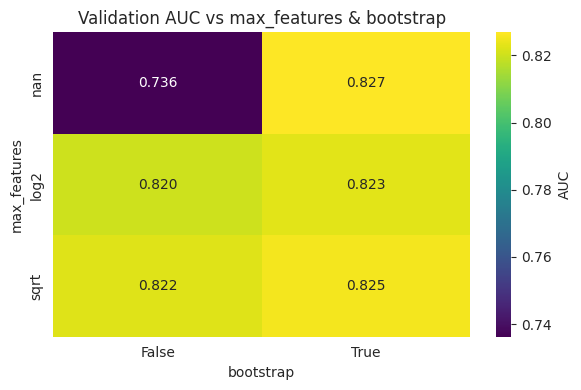

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

max_features_options = ['sqrt', 'log2', None]
bootstrap_options = [True, False]

scores = []

for mf in max_features_options:
    for bs in bootstrap_options:
        rf = RandomForestClassifier(
            n_estimators=125,
            max_depth=10,
            min_samples_leaf=5,
            max_features=mf,
            bootstrap=bs,
            random_state=1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((mf, bs, auc))

df_rf_extra = pd.DataFrame(scores, columns=['max_features', 'bootstrap', 'val_auc'])
display(df_rf_extra.sort_values(by="val_auc", ascending=False))

import seaborn as sns

pivot = df_rf_extra.pivot(index='max_features', columns='bootstrap', values='val_auc')

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis', cbar_kws={"label": "AUC"})
plt.title("Validation AUC vs max_features & bootstrap")
plt.ylabel("max_features")
plt.xlabel("bootstrap")
plt.tight_layout()
plt.show()



### 🔍 Analyse

* ✅ **Avec `bootstrap=True`**, les performances sont toujours meilleures, quelle que soit la valeur de `max_features`.
* ✅ `max_features=None` (utilisation de **toutes les features** à chaque split) donne ici le meilleur score **si et seulement si** `bootstrap=True`.
* ⚠️ **Combinaison `None` + `bootstrap=False`** dégrade fortement la performance (AUC = 0.736). Cela peut s’expliquer par :

  * L'absence de diversité (pas de tirage aléatoire des colonnes ni des lignes)
  * Un sur-apprentissage brutal dès les premiers splits.



### Extra 3
There's a variation of random forest caled "extremely randomized trees", or "extra trees". Instead of selecting the best split among all possible thresholds, it selects a few thresholds randomly and picks the best one among them. Because of that extra trees never overfit.


In [52]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score

# Entraînement sur le jeu de validation
et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features=None,
    bootstrap=True,   # ExtraTrees peut aussi utiliser le bootstrap (par défaut False)
    random_state=1
)
et.fit(X_train, y_train)

# Évaluation sur la validation
y_pred_et = et.predict_proba(X_val)[:, 1]
auc_et_val = roc_auc_score(y_val, y_pred_et)
print(f"ExtraTrees AUC (validation): {auc_et_val:.5f}")
# Re-entraîne sur tout le training set
et.fit(X_train_full, y_train_full)

# Évaluation finale sur le test
y_pred_test_et = et.predict_proba(X_test)[:, 1]
auc_et_test = roc_auc_score(y_test, y_pred_test_et)
print(f"✅ ExtraTrees AUC (test): {auc_et_test:.5f}")


ExtraTrees AUC (validation): 0.81424
✅ ExtraTrees AUC (test): 0.81518



### 📌 Remarques

* **Différence clé avec RandomForest** : au lieu de chercher la meilleure coupure parmi **toutes les valeurs possibles**, ExtraTrees **prend des coupures aléatoires**, ce qui apporte plus de **diversité**.
* Cela réduit le **risque d'overfitting**, mais peut aussi **introduire plus de biais** si mal configuré.
* ExtraTrees **peut être plus rapide** à entraîner car il ne cherche pas exhaustivement les meilleurs seuils.


### Extra 4 : In Scikit-Learn, they are implemented in ExtraTreesClassifier. Try it for this project.

### 🔍 **C’est une variante de RandomForestClassifier**.

Mais au lieu de chercher la **meilleure coupure possible** (meilleur seuil) à chaque split comme dans un arbre de décision ou un random forest…

👉 **Extra Trees sélectionne ces seuils de manière aléatoire** dans un sous-ensemble et prend celui qui donne le meilleur gain parmi ces tirages.

---

### ⚙️ Fonctionnement résumé

| Étape                      | RandomForest                        | ExtraTrees                                  |
| -------------------------- | ----------------------------------- | ------------------------------------------- |
| Sélection des colonnes     | Aléatoire                           | Aléatoire (pareil)                          |
| Sélection des données      | Bootstrap                           | Bootstrap ou pas                            |
| **Choix du seuil (split)** | **Optimisé sur toutes les valeurs** | **Tirage aléatoire parmi quelques valeurs** |

➡️ Extra Trees est donc **plus aléatoire**, plus rapide, et **souvent moins sujet à l’overfitting**, mais il peut avoir un peu plus de **biais**.

---

#### 🎯 Pourquoi on dit "peu de tuning" ?

#### ✅ Parce que **ExtraTrees est souvent robuste avec ses paramètres par défaut ou quasi-par défaut.**


### 🆚 Comparaison de la sensibilité au tuning

| Modèle         | Sensible au tuning ? | Pourquoi ?                                             |
| -------------- | -------------------- | ------------------------------------------------------ |
| DecisionTree   | OUI                  | Trop profond → overfitting, trop simple → sous-apprend |
| RandomForest   | MOYEN                | Bon compromis entre variance et biais                  |
| **ExtraTrees** | **FAIBLE**           | Grâce à l'aléa dans les splits                         |
| XGBoost        | OUI++                | Boosting = accumulation → très sensible à chaque param |


### 🧠 Analogie

> ExtraTrees, c’est comme lancer plusieurs fléchettes au hasard dans la bonne direction,
> plutôt que d’essayer d’ajuster chaque coup précisément.

C’est **moins précis**, mais **plus rapide** et souvent **suffisamment bon**.




📊 ExtraTrees AUC (val): 0.80003
✅ ExtraTrees AUC (test): 0.79711
        feature  importance
16  job=partime    0.183193
25   records=no    0.143853
26  records=yes    0.126477
27    seniority    0.109756
12       income    0.090589
7    home=owner    0.078680
1        amount    0.039495
13    job=fixed    0.039359
28         time    0.034667
2        assets    0.020039


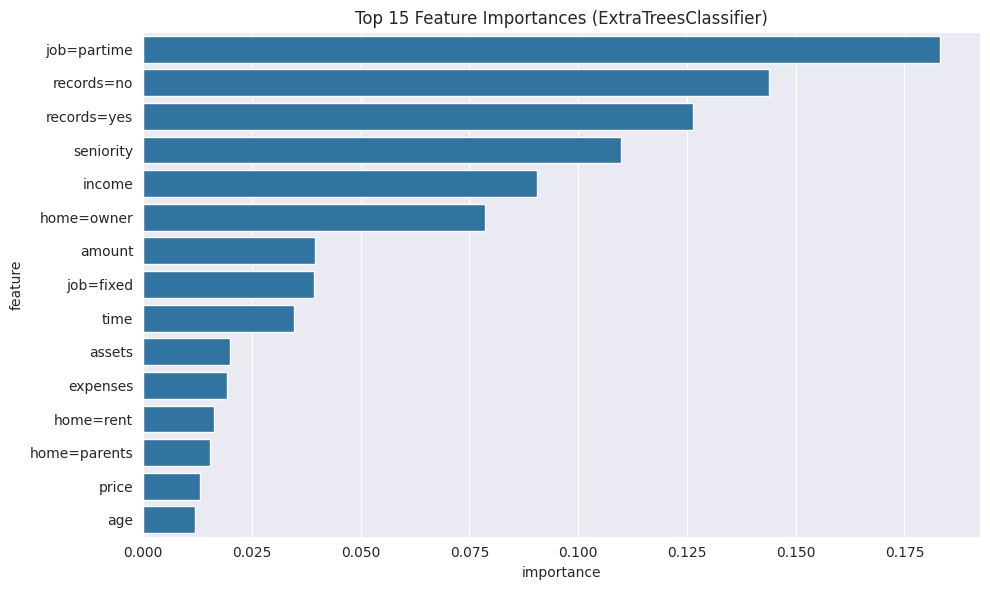

In [69]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score

# Configuration identique à RandomForest optimal
et = ExtraTreesClassifier(
    n_estimators=125,
    max_depth=10,
    min_samples_leaf=5,
    max_features=None,
    bootstrap=True,  # facultatif, par défaut False
    random_state=1
)

# Entraînement sur le jeu de validation
et.fit(X_train, y_train)

# Prédictions et AUC sur validation
y_pred_et = et.predict_proba(X_val)[:, 1]
auc_et_val = roc_auc_score(y_val, y_pred_et)

print(f"📊 ExtraTrees AUC (val): {auc_et_val:.5f}")
# Réentraîner sur l'ensemble du train (train + val)
et.fit(X_train_full, y_train_full)

# Évaluer sur test
y_pred_test_et = et.predict_proba(X_test)[:, 1]
auc_et_test = roc_auc_score(y_test, y_pred_test_et)

print(f"✅ ExtraTrees AUC (test): {auc_et_test:.5f}")
importances = et.feature_importances_
feature_names = dv.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))  # Top 10

# Optionnel : graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15))
plt.title("Top 15 Feature Importances (ExtraTreesClassifier)")
plt.tight_layout()
plt.show()


a### Extra 5 : XGBoost can deal with NAs - we don't have to do fillna for it. Check if not filling NA's help improve performance.


In [68]:
### ✅ **Étape 1 — Créer une version des données SANS `fillna(0)`**

def prepare_data_no_fillna(df):
    from sklearn.feature_extraction import DictVectorizer
    from sklearn.model_selection import train_test_split

    df = df.copy()

    df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=11)
    df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=11)

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_train_full = df_train_full.reset_index(drop=True)

    y_train_full = (df_train_full.status == 'default').astype(int).values
    y_test = (df_test.status == 'default').astype(int).values
    y_train = (df_train.status == 'default').astype(int).values
    y_val = (df_val.status == 'default').astype(int).values

    for df_ in [df_train, df_val, df_train_full, df_test]:
        del df_['status']

    # pas de fillna ici
    dict_train = df_train.to_dict(orient='records')
    dict_val = df_val.to_dict(orient='records')
    dict_train_full = df_train_full.to_dict(orient='records')
    dict_test = df_test.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dict_train)
    X_val = dv.transform(dict_val)
    X_train_full = dv.transform(dict_train_full)
    X_test = dv.transform(dict_test)

    return X_train_full, X_test, X_train, X_val, y_train_full, y_test, y_train, y_val, dv

### ✅ **Étape 2 — Recréer les données sans remplissage**

X_train_full_na, X_test_na, X_train_na, X_val_na, y_train_full_na, y_test_na, y_train_na, y_val_na, dv_na = prepare_data_no_fillna(df_origin)

### ✅ **Étape 3 — Entraîner un XGBoost directement sur ces données avec NAs**

import xgboost as xgb
feature_names = dv_na.get_feature_names_out().tolist()  # ✅ solution propre
dtrain_na = xgb.DMatrix(X_train_na, label=y_train_na, feature_names=feature_names)
dval_na = xgb.DMatrix(X_val_na, label=y_val_na, feature_names=feature_names)

xgb_params_na = {
    'eta': 0.05,
    'max_depth': 3,
    'min_child_weight': 30,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'lambda': 1.0,
    'alpha': 0.0,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    'seed': 1,
    'verbosity': 0,
}

watchlist_na = [(dtrain_na, 'train'), (dval_na, 'val')]

model_na = xgb.train(
    xgb_params_na,
    dtrain_na,
    num_boost_round=200,
    evals=watchlist_na,
    early_stopping_rounds=10,
    verbose_eval=False
)

### ✅ **Étape 4 — Comparer l'AUC avec et sans `fillna(0)`**
# AUC validation sur données avec NA non remplies
y_pred_val_na = model_na.predict(dval_na)
auc_val_na = roc_auc_score(y_val_na, y_pred_val_na)
print(f"📊 XGBoost AUC (val, avec NAs natifs): {auc_val_na:.5f}")

# Pour comparaison, reprendre la valeur AUC obtenue plus tôt avec la version remplie (`fillna(0)`), et la comparer :
X_train_full, X_test, X_train, X_val, y_train_full, y_test, y_train, y_val, dv = prepare_data(df_origin)
# 📌 Construire watchlist correcte pour la version avec `fillna(0)`
dtrain_filled = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dval_filled = xgb.DMatrix(X_val, label=y_val, feature_names=feature_names)

watchlist_filled = [(dtrain_filled, 'train'), (dval_filled, 'val')]

# 🧠 Entraîner modèle sur version avec fillna(0)
model_filled = xgb.train(
    xgb_params_na,
    dtrain_filled,
    num_boost_round=200,
    evals=watchlist_filled,
    early_stopping_rounds=10,
    verbose_eval=False
)

# ✅ Prédictions sur validation avec fillna(0)
y_pred_val_filled = model_filled.predict(dval_filled)
auc_val_filled = roc_auc_score(y_val, y_pred_val_filled)
print(f"📊 XGBoost AUC (val, avec fillna(0)): {auc_val_filled:.5f}")

print("\n ✅ Missing values in filled version (with fillna(0)):")
print(np.isnan(X_train).sum())  # should be 0
print(" 🧪 Missing values in NA version (no fillna):")
print(np.isnan(X_train_na).sum())  # total number of NaNs
# XGBoost gère très bien les NAs par défaut

📊 XGBoost AUC (val, avec NAs natifs): 0.83268
📊 XGBoost AUC (val, avec fillna(0)): 0.83275

 ✅ Missing values in filled version (with fillna(0)):
0
🧪 Missing values in NA version (no fillna):
66



 ### Extra 6 : Experiment with other XGBoost parameters: subsample and colsample_bytree.

Ces deux paramètres contrôlent la **quantité de données et de variables utilisées par chaque arbre**, et ils sont très utiles pour :

* **Réduire l'overfitting**
* **Améliorer la robustesse**
* **Augmenter la diversité des arbres**

---

## 🔧 Paramètres à explorer

| Paramètre          | Description                                                           |
| ------------------ | --------------------------------------------------------------------- |
| `subsample`        | Proportion d’exemples (lignes) utilisés à chaque arbre (entre 0 et 1) |
| `colsample_bytree` | Proportion de variables (colonnes/features) utilisées à chaque arbre  |




## ✅ Analyse attendue

* Les meilleurs résultats se situent **autour de `0.7–1.0`** pour ces deux paramètres.
* Des valeurs trop faibles (<0.5) **introduisent trop de bruit** et nuisent à la performance.
* Des valeurs entre 0.6 et 0.9 sont souvent un bon compromis (moins d’overfitting, bonne stabilité).



   subsample  colsample_bytree  val_auc
7        1.0               0.7  0.83276
8        1.0               1.0  0.83275
6        1.0               0.5  0.83219
5        0.7               1.0  0.83196
4        0.7               0.7  0.83110
2        0.5               1.0  0.82802
1        0.5               0.7  0.82735
3        0.7               0.5  0.80196
0        0.5               0.5  0.79229


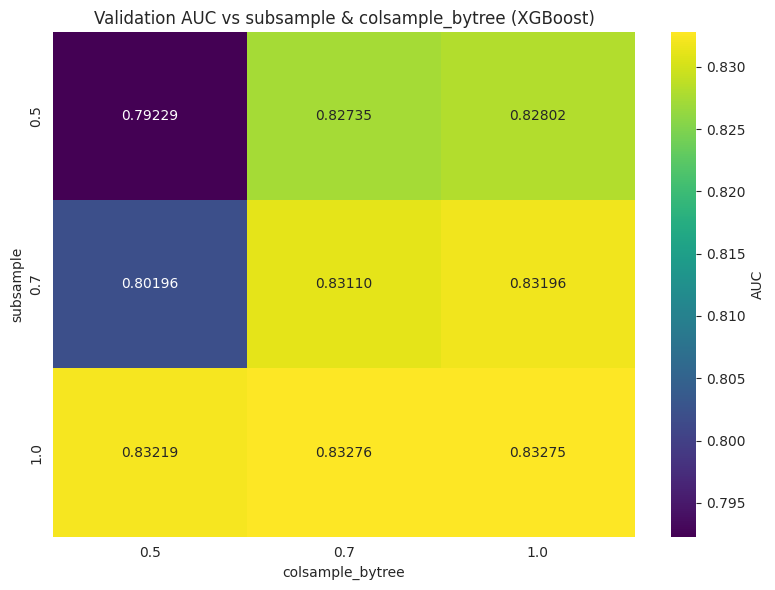

In [70]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import pandas as pd
from itertools import product
from IPython.utils import io

subsamples = [0.5, 0.7, 1.0]
colsamples = [0.5, 0.7, 1.0]
results = []

for subsample, colsample in product(subsamples, colsamples):
    params = {
        'eta': 0.05,
        'max_depth': 3,
        'min_child_weight': 30,
        'lambda': 1.0,
        'alpha': 0.0,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'subsample': subsample,
        'colsample_bytree': colsample,
        'seed': 1,
        'nthread': 8,
        'verbosity': 0,
    }

    with io.capture_output() as output:
        model = xgb.train(
            params,
            dtrain,
            num_boost_round=200,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=10,
            verbose_eval=False
        )

    y_pred = model.predict(dval)
    auc = roc_auc_score(y_val, y_pred)

    results.append({
        'subsample': subsample,
        'colsample_bytree': colsample,
        'val_auc': round(auc, 5)
    })

df_sub_col = pd.DataFrame(results)
df_sub_col_pivot = df_sub_col.pivot(index='subsample', columns='colsample_bytree', values='val_auc')
print(df_sub_col.sort_values("val_auc", ascending=False))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_sub_col_pivot, annot=True, fmt=".5f", cmap="viridis", cbar_kws={"label": "AUC"})
plt.title("Validation AUC vs subsample & colsample_bytree (XGBoost)")
plt.xlabel("colsample_bytree")
plt.ylabel("subsample")
plt.tight_layout()
plt.show()

  ### Extra 7 : When selecting the best split, decision trees find the most useful features. This information can be used for understanding which features are more important than otheres. See example here for random forest (it's the same for plain decision trees) and for xgboost
> 👉 Les **arbres de décision** (DecisionTree, RandomForest, ExtraTrees, XGBoost...) **calculent automatiquement** quelles variables sont les plus utiles, en se basant sur **leur contribution aux splits**.

---

## 🧠 Comment l’importance est calculée ?

| Méthode                 | Description simplifiée                                             |
| ----------------------- | ------------------------------------------------------------------ |
| `feature_importances_`  | Importance = gain moyen de chaque split sur cette variable         |
| XGBoost (`get_score()`) | Importance = nb d’apparitions, gain total ou gain moyen            |
| SHAP (avancé)           | Importance = impact marginal moyen de chaque feature sur la sortie |

## 📌 Quelle importance utiliser ?

| Type (`importance_type`) | Interprétation                                     |
| ------------------------ | -------------------------------------------------- |
| `'weight'`               | Nombre de fois qu'une feature est utilisée         |
| `'gain'`                 | Gain moyen de chaque split utilisant cette feature |
| `'cover'`                | Nombre d'exemples touchés par ces splits           |

➡️ **`gain`** est souvent le plus pertinent pour les modèles prédictifs.






        feature  importance
12       income    0.151424
27    seniority    0.130958
25   records=no    0.089204
1        amount    0.082209
2        assets    0.077460
26  records=yes    0.075887
24        price    0.067462
16  job=partime    0.062280
0           age    0.057827
13    job=fixed    0.041264


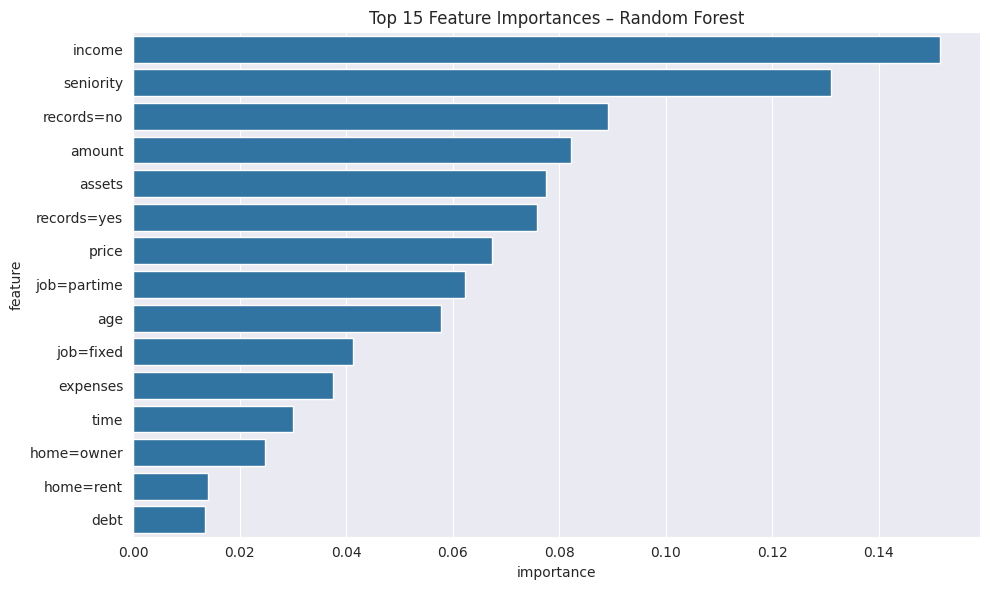

         feature  importance
14    records=no   27.813709
11   job=partime   27.784176
15     seniority   24.957977
9      job=fixed   17.272022
7      home=rent   17.254341
8         income   15.121634
2         assets   14.137755
5     home=owner   11.727364
1         amount    8.969364
6   home=parents    7.259501


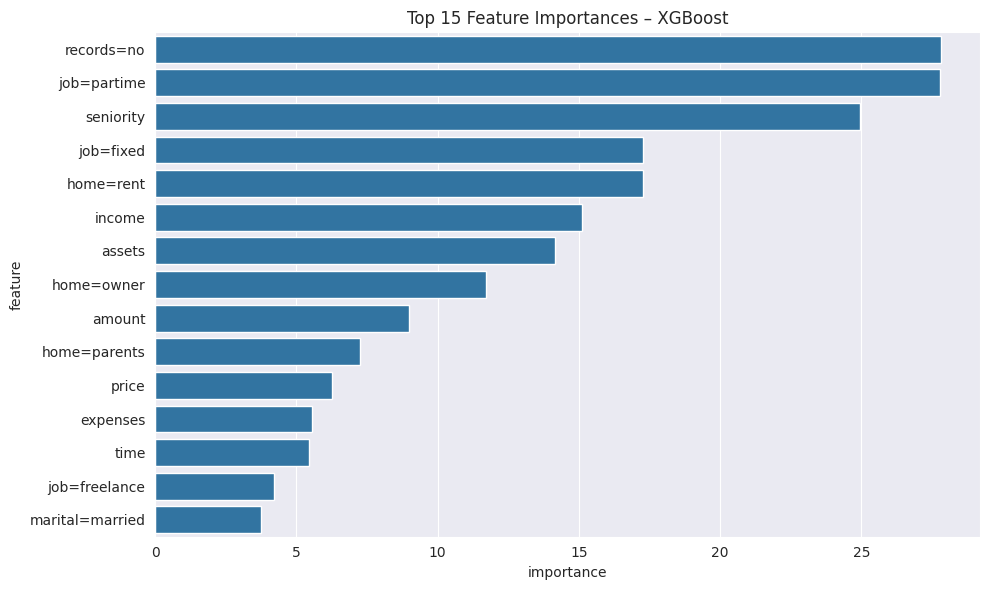

        feature  importance_rf  importance_xgb
12       income       0.151424       15.121634
27    seniority       0.130958       24.957977
25   records=no       0.089204       27.813709
1        amount       0.082209        8.969364
2        assets       0.077460       14.137755
26  records=yes       0.075887        0.000000
24        price       0.067462        6.265039
16  job=partime       0.062280       27.784176
0           age       0.057827        3.413922
13    job=fixed       0.041264       17.272022


In [80]:
importances = rf.feature_importances_  # ou et.feature_importances_
feature_names = dv.get_feature_names_out()

rf_feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(rf_feat_df.head(10))

# Graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_feat_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances – Random Forest")
plt.tight_layout()
plt.show()
# Entraînement
model = xgb.train(params, dtrain, num_boost_round=200)

# Récupération des scores (importance brute : nb d’apparitions par feature)
importance = model.get_score(importance_type='gain')  # ou 'gain', 'cover'

# Formater en DataFrame
xgb_feat_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

print(xgb_feat_df.head(10))

# Graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_feat_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances – XGBoost")
plt.tight_layout()
plt.show()

merged = pd.merge(rf_feat_df, xgb_feat_df, on='feature', how='outer', suffixes=('_rf', '_xgb')).fillna(0)
print(merged.sort_values("importance_rf", ascending=False).head(10))


In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# entraînement
rf = RandomForestClassifier(
    n_estimators=125,
    max_depth=10,
    min_samples_leaf=5,
    random_state=1
)
rf.fit(X_train, y_train)

result = permutation_importance(
    rf, X_val, y_val,
    scoring='roc_auc',  # ou 'accuracy', 'neg_log_loss' selon le contexte
    n_repeats=10,
    random_state=1,
    n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': dv.get_feature_names_out(),
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# print(perm_df.head(10))

# Assure-toi que perm_df a bien une colonne "feature"
merged_all = pd.merge(
    merged,
    perm_df[['feature', 'importance_mean', 'importance_std']],
    on='feature',
    how='left'
).fillna(0)
print(merged_all.sort_values("importance_rf", ascending=False).head(10))

        feature  importance_rf  importance_xgb  importance_mean  \
12       income       0.151424       15.121634         0.058910   
27    seniority       0.130958       24.957977         0.024285   
25   records=no       0.089204       27.813709         0.022943   
1        amount       0.082209        8.969364         0.028332   
2        assets       0.077460       14.137755         0.017593   
26  records=yes       0.075887        0.000000         0.013229   
24        price       0.067462        6.265039         0.003083   
16  job=partime       0.062280       27.784176         0.012733   
0           age       0.057827        3.413922         0.001240   
13    job=fixed       0.041264       17.272022         0.001352   

    importance_std  
12        0.007066  
27        0.007292  
25        0.004546  
1         0.004619  
2         0.005555  
26        0.004226  
24        0.001875  
16        0.003465  
0         0.002264  
13        0.002989  


  ### Extra 8 : Trees can also be used for solving the regression problems: check DecisionTreeRegressor, RandomForestRegressor and the objective=reg:squarederror parameter for XGBoost.
Test avec 'amount' to determine how much money is ask per client

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

# Étape 1 : reséparer les données
df_train_full, df_test = train_test_split(df_origin, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=11)

# Reset index (bonnes pratiques)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_train_full = df_train_full.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Étape 2 : Séparer la cible de régression
y_train = df_train['amount'].values
y_val = df_val['amount'].values

# Supprimer `amount` des features pour éviter fuite de données
for df_ in [df_train, df_val]:
    df_.drop(columns=['amount'], inplace=True)

# Vectorisation
dict_train = df_train.to_dict(orient='records')
dict_val = df_val.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dict_train)
X_val = dv.transform(dict_val)


from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import numpy as np

# Decision Tree
reg = DecisionTreeRegressor(max_depth=5, random_state=1)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_val)
rmse_dt = np.sqrt(mean_squared_error(y_val, y_pred))
# print(f"📊 DecisionTreeRegressor RMSE: {rmse_dt:.2f}")

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
# print(f"📊 RandomForestRegressor RMSE: {rmse_rf:.2f}")

# XGBoost
feature_names = dv.get_feature_names_out().tolist()
dtrain_reg = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dval_reg = xgb.DMatrix(X_val, label=y_val, feature_names=feature_names)

params_reg = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.1,
    'nthread': 8,
    'seed': 1
}

model_reg = xgb.train(
    params_reg,
    dtrain_reg,
    num_boost_round=200,
    evals=[(dtrain_reg, 'train'), (dval_reg, 'val')],
    early_stopping_rounds=10,
    verbose_eval=False
)

y_pred_xgb = model_reg.predict(dval_reg)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
print(f"📊 XGBoost Regressor RMSE: {rmse_xgb:.2f}")

# Résumé statistique des montants
print("📊 Distribution de 'amount' :")
print(df_origin['amount'].describe())
print()

# Valeurs issues de df_origin['amount'].describe()
mean_amount = df_origin['amount'].mean()

# Affichage des erreurs relatives
print(f"🌲 DecisionTreeRegressor RMSE: {rmse_dt:.2f} → relative error: {rmse_dt / mean_amount:.2%}")
print(f"🌳 RandomForestRegressor RMSE: {rmse_rf:.2f} → relative error: {rmse_rf / mean_amount:.2%}")
print(f"⚡ XGBoost Regressor RMSE: {rmse_xgb:.2f} → relative error: {rmse_xgb / mean_amount:.2%}")


📊 XGBoost Regressor RMSE: 280.78
📊 Distribution de 'amount' :
count    4454.000000
mean     1038.918276
std       474.545999
min       100.000000
25%       700.000000
50%      1000.000000
75%      1300.000000
max      5000.000000
Name: amount, dtype: float64

🌲 DecisionTreeRegressor RMSE: 290.30 → relative error: 27.94%
🌳 RandomForestRegressor RMSE: 282.26 → relative error: 27.17%
⚡ XGBoost Regressor RMSE: 280.78 → relative error: 27.03%


In [100]:
import pandas as pd

# Gain = amélioration moyenne de la perte par split (plus pertinent que weight)
importance_gain = model_reg.get_score(importance_type='gain')

# Convertir en DataFrame et trier
importance_df = pd.DataFrame.from_dict(importance_gain, orient='index', columns=['gain'])
importance_df = importance_df.sort_values(by='gain', ascending=False)

# Afficher les 5 plus importantes
print("🔝 Top 5 features (gain):")
print(importance_df.head(15))


🔝 Top 5 features (gain):
                           gain
price              2.764501e+06
time               2.252408e+06
marital=separated  8.266301e+05
status=default     4.152825e+05
job=freelance      3.704968e+05
home=other         2.537181e+05
home=parents       2.211314e+05
income             2.152175e+05
expenses           2.107114e+05
job=fixed          2.087076e+05
assets             2.040566e+05
seniority          1.816500e+05
marital=widow      1.770278e+05
home=rent          1.750700e+05
home=owner         1.723588e+05
